In [2]:
import numpy as np
import pandas as pd

from helper_functions import *

from SPM import subspace_power_method
from ICA_code import cumulant_tensors
import matplotlib.pyplot as plt
from pcpca import PCPCA
from contrastive import CPCA
# from os.path import join as pjoin
# from scipy.io import mmread
from sklearn.decomposition import PCA
# import torch
from cICA_functions import *

In [5]:
# the csv dataset "human_data.csv", "gorilla_data.csv", "chimp_data.csv" and the useful_genes_filtered.csv
# are avaliable for download ar https://drive.google.com/drive/folders/1c3Zv2Ws6YBc9ZPE05Mw_l9wZoe3sKP8D?dmr=1&ec=wgc-drive-globalnav-goto
# raw data downloaded from https://labshare.cshl.edu/shares/gillislab/resource/Primate_MTG_coexp/ and preprocessed via the code in monkey_human_r

useful_genes=pd.read_csv('monkey_human/useful_genes_filtered.csv')
evolutional_genes=useful_genes[useful_genes['10']=='Diverged_in_both']['0'].values
non_evolutional_genes=useful_genes[useful_genes['10']=='Diverged_in_single-cell']['0'].values


In [ ]:
# human=pd.read_csv('human_data.csv')
# gorilla=pd.read_csv('gorilla_data.csv')
# chimp=pd.read_csv('chimp_data.csv')
# human_filtered=human[human['Unnamed: 0'].isin(useful_genes['0'])]
# gorilla_filtered=gorilla[gorilla['Unnamed: 0'].isin(useful_genes['0'])]
# chimp_filtered=chimp[chimp['Unnamed: 0'].isin(useful_genes['0'])]


# human_evolutional=human[human['Unnamed: 0'].isin(evolutional_genes)]
# gorilla_evolutional=gorilla[gorilla['Unnamed: 0'].isin(evolutional_genes)]
# chimp_evolutional=chimp[chimp['Unnamed: 0'].isin(evolutional_genes)]

# human_non_evolutional=human[human['Unnamed: 0'].isin(non_evolutional_genes)]
# gorilla_non_evolutional=gorilla[gorilla['Unnamed: 0'].isin(non_evolutional_genes)]
# chimp_non_evolutional=chimp[chimp['Unnamed: 0'].isin(non_evolutional_genes)]


# human_evolutional_array=human_evolutional.values[:,2:].T
# std_values = np.std(human_evolutional_array.astype(float), axis=0)
# indices=np.argsort(std_values)[-15:]
# evolutional_genes_15=evolutional_genes[indices]


# gorilla_non_evolutional_array=gorilla_non_evolutional.values[:,2:].T
# chimp_non_evolutional_array=chimp_non_evolutional.values[:,2:].T
# std_values_non_evolutional=np.std(np.vstack((gorilla_non_evolutional_array, chimp_non_evolutional_array)).astype(float), axis=0)
# indices_non_evolutional=np.argsort(std_values_non_evolutional)[-15:]
# non_evolutional_genes_15=non_evolutional_genes[indices_non_evolutional]


# genes_name_first_15_evolutional=np.vstack((evolutional_genes_15.reshape(-1,1), non_evolutional_genes_15.reshape(-1,1)))
# genes_name_first_15_evolutional=genes_name_first_15_evolutional.reshape(-1)


# human_30=human[human['Unnamed: 0'].isin(genes_name_first_15_evolutional)].T.iloc[1:,:]
# gorilla_30=gorilla[gorilla['Unnamed: 0'].isin(genes_name_first_15_evolutional)].T.iloc[1:,:]
# chimp_30=chimp[chimp['Unnamed: 0'].isin(genes_name_first_15_evolutional)].T.iloc[1:,:]


# # Reset the index
# human_30.rename(columns=human_30.iloc[0,:], inplace=True)
# human_30.drop(human_30.index[0],inplace=True)  
# gorilla_30.rename(columns=gorilla_30.iloc[0,:], inplace=True)
# gorilla_30.drop(gorilla_30.index[0],inplace=True)
# chimp_30.rename(columns=chimp_30.iloc[0,:], inplace=True)
# chimp_30.drop(chimp_30.index[0],inplace=True)


# primate=pd.concat([gorilla_30,chimp_30], axis=0)
# primate.to_csv('monkey_human/Y.csv')
# human_30.to_csv('monkey_human/X.csv')

# genes_name_first_15_evolutional[15:]

array(['LUC7L3', 'RBKS', 'RBM7', 'AP4S1', 'CLCN1', 'CLASP1', 'ADTRP',
       'CNNM3', 'NDUFAF7', 'CNIH4', 'RPUSD2', 'NELFCD', 'RPP14', 'ROMO1',
       'RNF181'], dtype=object)

In [ ]:
X=pd.read_csv('monkey_human/X.csv').values[:,1:].astype(float)
Y=pd.read_csv('monkey_human/Y.csv').values[:,1:].astype(float)
# k2_f,k4_f=cumulant_tensors(X)
# k2_b,k4_b=cumulant_tensors(Y)
# np.save('k2_f.npy',k2_f)
# np.save('k4_f.npy',k4_f)
# np.save('k2_b.npy',k2_b)
# np.save('k4_b.npy',k4_b)
k2_f=np.load('monkey_human/k2_f.npy')
k4_f=np.load('monkey_human/k4_f.npy')
k2_b=np.load('monkey_human/k2_b.npy')
k4_b=np.load('monkey_human/k4_b.npy')

Text(0, 0.5, 'eigenvalue')

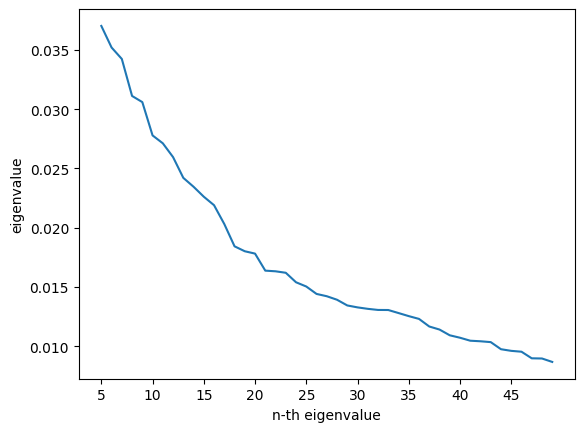

In [9]:
# choose r=22
I=k4_b.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.plot(range(5,50),abs(D)[5:50])
plt.xticks(range(5,50,5))
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')

Text(0, 0.5, 'eigenvalue')

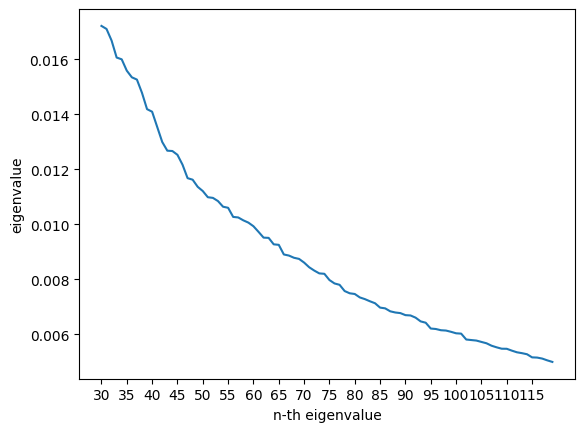

In [10]:
# choose r+l=46
I=k4_f.shape[0]
D,V=eig2(k4_f.reshape(I**2,I**2))
plt.plot(range(30,120),abs(D)[30:120])
plt.xticks(range(30,120,5))
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')

In [ ]:
# score function to count how many of the first 15 evolutional genes are selected
def score(index):
    count=0
    for i in index:
        if i<15:
            count+=1
    return count

# compare the top two patterns of each method and see if the entries with large absolute value correspond to the evolutional genes

In [ ]:
#cICA
np.random.seed(0)
a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=22,l=46-22)
index_1=np.argsort(abs(b_s_sorted[:,0]))[-15:]
index_2=np.argsort(abs(b_s_sorted[:,1]))[-15:]
score(index_1),score(index_2),index_1,index_2


(10,
 13,
 array([ 0,  1, 19, 28, 26,  3, 23, 11, 10,  5, 18,  2,  4, 13, 12]),
 array([ 8, 14, 10,  5,  4,  6,  3, 11,  1,  2, 28, 18, 13, 12,  0]))

In [17]:
set(index_1).union(set(index_2))

{0, 1, 2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 18, 19, 23, 26, 28}

In [ ]:
#ICA
np.random.seed(0)
a_s,b_s_sorted_ICA,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=0,l=46)
index_1=np.argsort(abs(b_s_sorted_ICA[:,0]))[-15:]
index_2=np.argsort(abs(b_s_sorted_ICA[:,1]))[-15:]
score(index_1),score(index_2),set(index_1).union(set(index_2))

(9, 10, {0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 17, 18, 19, 20, 21, 23, 26})

In [24]:
#PCPCA choose gamma
score_list_1=[]
score_list_2=[]
score_list_3=[]
score_list_4 = []
b_list=[]
n, m = X.shape[0], Y.shape[0]
for gamma in np.linspace(0,0.9,100):
    pcpca = PCPCA(gamma=n/m*gamma, n_components=2)
    X_reduced,Y_reduced=pcpca.fit_transform(X.T,Y.T)
    b=pcpca.W_mle
    b_list.append(b)
    score_list_1.append(score(np.argsort(abs(b[:,0]))[-15:]))
    score_list_2.append(score(np.argsort(abs(b[:,1]))[-15:]))
    score_list_3.append(score(np.argsort(abs(b[:,0]))[-15:])+score(np.argsort(abs(b[:,1]))[-15:]))
    score_list_4.append(score(set(np.argsort(abs(b[:,0]))[-15:]).union(set(np.argsort(abs(b[:,1]))[-15:]))))

print(max(score_list_1),max(score_list_2),max(score_list_3))
index=np.argmax(np.array(score_list_3))
gamma=np.linspace(0,0.9,100)[index]
print(gamma)

10 11 21
0.0


In [ ]:
# have a closer look at the result of PCPCA with the chosen gamma
gamma = 0
n, m = X.shape[0], Y.shape[0]
pcpca = PCPCA(gamma=n/m*gamma, n_components=2)
X_reduced,Y_reduced=pcpca.fit_transform(X.T,Y.T)
b=pcpca.W_mle
np.argsort(abs(b[:,0]))[-15:],np.argsort(abs(b[:,1]))[-15:],set(np.argsort(abs(b[:,0]))[-15:]).union(set(np.argsort(abs(b[:,1]))[-15:]))


(array([12, 19, 23, 18, 10,  2, 17,  1,  3, 28, 11,  5,  4, 13,  6]),
 array([23,  8, 26, 29, 11, 10,  0,  4,  2,  1,  3, 28,  5,  6, 13]),
 {0, 1, 2, 3, 4, 5, 6, 8, 10, 11, 12, 13, 17, 18, 19, 23, 26, 28, 29})

In [32]:
# cPCA choose alpha
k2_f = np.cov(X,rowvar=False)
k2_b = np.cov(Y,rowvar=False)
#cPCA
mdl=CPCA()
score_list_1=[]
score_list_2=[]
score_list_3=[]
alphas = np.logspace(-3,3,100)
for alpha in alphas:
    D,V=np.linalg.eig(k2_f-alpha*k2_b)
    eig_idx = np.argpartition(D, -2)[-2:]
    b_cpca=V[:,eig_idx]
    score_list_1.append(score(np.argsort(abs(b_cpca[:,0]))[-15:]))
    score_list_2.append(score(np.argsort(abs(b_cpca[:,1]))[-15:]))
    score_list_3.append(score(np.argsort(abs(b_cpca[:,0]))[-15:])+score(np.argsort(abs(b_cpca[:,1]))[-15:]))
    score_list_4.append(score(set(np.argsort(abs(b_cpca[:,0]))[-15:]).union(set(np.argsort(abs(b_cpca[:,1]))[-15:]))))
print(max(score_list_1),max(score_list_2),max(score_list_3),max(score_list_4))
alpha=alphas[np.argmax(score_list_3)]
alpha

10 10 20 12


(0.1747528400007685, 0.001)

In [ ]:
# have a closer look at the result of cPCA with the chosen alpha
alpha=0.1747528400007685
D,V=np.linalg.eig(k2_f-alpha*k2_b)
eig_idx = np.argpartition(D, -2)[-2:]
b_cpca=V[:,eig_idx]
cpca_top_15= np.argsort(abs(b_cpca[:,0]))[-15:]
cpca_top_15_2= np.argsort(abs(b_cpca[:,1]))[-15:]
cpca_top_15, cpca_top_15_2, set(cpca_top_15).union(set(cpca_top_15_2))

(array([ 0, 19, 26, 13,  2,  3, 23, 10, 17, 11, 18,  4,  5,  6, 12]),
 array([15, 24, 28,  9, 12,  1,  3,  2,  0, 29, 17,  5,  6,  4, 13]),
 {0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 15, 17, 18, 19, 23, 24, 26, 28, 29})

In [27]:
# hierachical tensor decomp of k4_f-gamma k4_b, choose gamma
score_list_1=[]
score_list_2=[]
score_list_3=[]
score_list_4=[]
for gamma in np.logspace(-3,3,num=100):
    gamma=gamma**2 
    b_s_sorted_proportional,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,46-22)
    score_list_1.append(score(np.argsort(abs(b_s_sorted_proportional[:,0]))[-15:]))
    score_list_2.append(score(np.argsort(abs(b_s_sorted_proportional[:,1]))[-15:]))
    score_list_3.append(score(np.argsort(abs(b_s_sorted_proportional[:,0]))[-15:])+score(np.argsort(abs(b_s_sorted_proportional[:,1]))[-15:]))
    score_list_4.append(score(set(np.argsort(abs(b_s_sorted_proportional[:,0]))[-15:]).union(set(np.argsort(abs(b_s_sorted_proportional[:,1]))[-15:]))))
index=np.argmax(score_list_3)
gamma=(np.logspace(-3,3,num=100)[index])**2
print(gamma)
b_s_sorted_proportional,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,46-22)
index_1=np.argsort(abs(b_s_sorted_proportional[:,0]))[-15:]
index_2=np.argsort(abs(b_s_sorted_proportional[:,1]))[-15:]
score(index_1),score(index_2),set(index_1).union(set(index_2))

0.030538555088334193


(10, 10, {0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 17, 18, 19, 21, 23, 26})

In [ ]:
# have a closer look at the result of HTD with the chosen gamma
gamma=0.030538555088334193
b_s_sorted_proportional,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,46-22)
index_1=np.argsort(abs(b_s_sorted_proportional[:,0]))[-15:]
index_2=np.argsort(abs(b_s_sorted_proportional[:,1]))[-15:]
score(index_1),score(index_2),set(index_1).union(set(index_2))

(10, 10, {0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 13, 17, 18, 19, 21, 23, 26})

In [15]:
Y.shape

(20000, 30)

In [21]:
# PCA 

pca = PCA(n_components=2)
stack = np.vstack([X,Y])
pca.fit_transform(X)
b_pca = pca.components_.T

In [ ]:
# function to check similarities of learned patterns by different methods
def inner_products(a,b):
    inner_list = []
    index_list  = [[0,0],[0,1],[1,0],[1,1]]
    for index in index_list:
        index_1=index[0]
        index_2=index[1]
        inner_list.append(np.sum(a[:,index_1]*b[:,index_2]))
    return inner_list

In [39]:
b[:,0]=b[:,0]/np.linalg.norm( b[:,0])
b[:,1]=b[:,1]/np.linalg.norm( b[:,1])

print("ICA vs cICA")
print(inner_products(b_s_sorted,b_s_sorted_ICA))

print("ICA vs proportional cICA")
print(inner_products(b_s_sorted,b_s_sorted_proportional))

print("cPCA vs cICA")
print(inner_products(b_s_sorted,b_cpca))

print("PCPCA vs cICA")
print(inner_products(b_s_sorted,b))

print("PCA vs cICA")
print(inner_products(b_s_sorted,b_pca))


## first pattern of cICA quite close to second pattern of ICA and proportional ICA (inner product 0.99, the other inner product 0.64)
## first pattern of cICA not far away from first pattern of PCA and cPCA (inner product 0.8)


ICA vs cICA
[-0.668855390399274, -0.9968363561264341, 0.025875235422560487, 0.641827426142069]
ICA vs proportional cICA
[-0.6408546254455783, -0.9967019927308355, 0.08671779497445169, 0.6424576598014737]
cPCA vs cICA
[-0.8547722370613999, -0.18971594813243575, 0.6618500255629011, 0.3246869082987784]
PCPCA vs cICA
[0.07641450771824088, 0.15683660088976684, -0.09544899055252959, -0.28690928110422614]
PCA vs cICA
[-0.8059595981802417, -0.18965621966572488, 0.6465200190709288, 0.324588777502115]
